In [ ]:
# %load_ext autoreload
# %autoreload 2

In [ ]:
# if google colab
use_colab = True

# download packages
!pip install pypose
!pip install kornia

# mount drive with data
from google.colab import drive
drive.mount('/content/drive')

# clone repo
%cd /content/
!git clone https://github.com/MarcinJanis/SonarOdometry.git
%cd SonarOdometry

In [ ]:
import os
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import cv2
from scipy.spatial.transform import Rotation as R

from box import Box
import yaml

import matplotlib.pyplot as plt
import plotly.graph_objects as go

from tqdm import tqdm
import random
import time

root_dir = os.path.abspath('../..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.data_loader.evaluation_data_generator import DataGenerator
from src.data_loader.metrics import eval_metrics_2d


In [ ]:
if use_colab:
    # path to directory with repo
    root_dir = '/content/SonarOdometry'
    # path to sonar images specific sequence to evaluate
    data_root_dir =  '/content/drive/MyDrive/Studia/SonarOdometryDataset/SonarOdometryDataset_sample/test_scenarios/seq_2'
else:
    # path to directory with repo
    root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry'
    # path to sonar images specific sequence to evaluate
    data_root_dir =  os.path.join(root_dir, 'SonarOdometryDataset/test_scenarios/seq_3')

# configuration paths
model_config_pth = os.path.join(root_dir, 'config/model_loftr_sim.yaml')
sonar_config_pth = os.path.join(root_dir, 'config/sonar_sim.yaml')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(model_config_pth, "r") as f:
            model_config = Box(yaml.safe_load(f))

with open(sonar_config_pth, "r") as f:
            sonar_config = Box(yaml.safe_load(f))


# Import data generator

from src.data_loader.transforms import SonarDatasetTranforms

# fls_resolution = (model_config.input_dimensions.polar_height , model_config.input_dimensions.polar_width ) # for own ds
fls_resolution = (model_config.input.polar_height, model_config.input.polar_width) 
data_generator = DataGenerator(data_root_dir, device, fls_resolution=fls_resolution, transforms = SonarDatasetTranforms, calibration = None)
data_lenght = data_generator.get_len()
print(f'Data series lenght: {data_lenght}')

Data generator initialized.
Data series lenght: 1000


In [ ]:
import torch
import torch.nn.functional as F
import torch.nn as nn 
from kornia.feature import LoFTR

import numpy as np 
import cv2 

class sonar_odometry(nn.Module):
  
    def __init__(self, model_config, sonar_config, device):
            
            super().__init__()
                       
            self.device = device 

            # --- Configuration ---

            # extrinsic calib 
            yaw_offset = sonar_config.position.yaw
            x_offset = sonar_config.position.x
            y_offset = sonar_config.position.y

            self.T_R_S_2d = np.array([
                [np.cos(yaw_offset), -np.sin(yaw_offset), x_offset],
                [np.sin(yaw_offset),  np.cos(yaw_offset), y_offset],
                [0,                   0,                  1]
            ]) # Transform matrix Robot -> Sonar frame
            # assumption -> roll and pitch = 0 
            self.T_S_R_2d = np.linalg.inv(self.T_R_S_2d) # Transform matrix Sonar -> Robot frame

            # Mapping of local to global frame of refernce
            self.axis_map = model_config.setup.axis_map # 'sim' (for own dataset) or 'aracati' 

            # Depth compesation param - only if depth data available
            self.depth_compesation = model_config.setup.use_depth_compesation       

            # Filtering: Preprocessing (MedianBlur + CLAHE)
            self.use_fls_filter = model_config.filtering.use_fls_filter

            # Filtering: Spatial bucketing param
            self.use_spatial_bucketing = model_config.filtering.use_spatial_bucketing
            self.bucket_grid = (model_config.setup.bucket_grid, model_config.setup.bucket_grid) 
            self.max_pts_per_bucket = model_config.setup.max_pts_per_bucket      
            
            # Kabsh motion model param
            self.use_weighted_kabsch = model_config.filtering.use_weighted_kabsch

            # Range masking param
            self.use_range_masking = model_config.filtering.use_range_masking
            self.max_valid_range_ratio = model_config.filtering.range_masking_max_range
            
            # Key frame management param
            self.key_frames = model_config.key_frames.use 
            self.window_size = self.key_frames.window_size
            self.key_frames_min_dist = model_config.key_frames.min_dist
            self.key_frames_min_rot = model_config.key_frames.min_rot
            self.key_frame_timeout = model_config.key_frames.max_skip_frames
            
            # Feature matching param
            self.pts_match_thresh = model_config.feature_matching.pts_match_thresh
            self.ransac_thresh = model_config.feature_matching.ransac_thresh
            self.min_inliers_abs = model_config.feature_matching.min_inliers_abs
            self.min_inliers_ratio = model_config.feature_matching.min_inliers_ratio

            # Input format and shape
            self.input_format = model_config.input.format
            if self.input_format == 'polar':
                h = model_config.input_dimensions.polar_height
                self.cart_frame_size = (h, 2 * h)
            else:
                self.cart_frame_size = (model_config.input_dimensions.cart_height, 
                                        model_config.input_dimensions.cart_width)

            # Sonar parameters
            self.r_min = sonar_config.range.min
            self.r_max = sonar_config.range.max
            self.theta_max = sonar_config.fov.horizontal

            # --- Modules --- 
            self.match_points = LoFTR(pretrained='outdoor').to(device).eval()

            # --- Iner State --- 
            self.sliding_window = [] 
            self.current_pose = None
            self.last_frame_data = None 
            
            self.skipped_frames = 0 

            self.polar2cart_grid = None
            self.polar2cart_mask = None

    # === Filtering methods === 

    def fls_filter(self, frame):
        device = frame.device 
        b, c, h, w = frame.shape
        # norm torch tensor -> np array
        frame_np = frame.squeeze().detach().cpu().numpy()
        frame_uint8 = np.clip(frame_np * 255.0, 0, 255).astype(np.uint8)
        # median blur
        blured = cv2.medianBlur(frame_uint8, ksize=3)
        # bilateral filter
        bilateral = cv2.bilateralFilter(blured, d=5, sigmaColor=25, sigmaSpace=5)
        # histogram equalization - CLAHE
        clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
        filtered = clahe.apply(bilateral)
        # np array -> norm torch tensor
        filtered_float = filtered.astype(np.float32) / 255.0
        frame_torch = torch.tensor(filtered_float, device=device).unsqueeze(0)
        return frame_torch

    def _apply_spatial_bucketing(self, pts1, pts2, conf):

        out_h, out_w = self.cart_frame_size
        grid_rows, grid_cols = self.bucket_grid
        
        dy = out_h / grid_rows
        dx = out_w / grid_cols
        
        N = pts1.shape[0]
        if N == 0:
            return pts1, pts2, conf

        # cell idx for each pt
        c_idx = (pts1[:, 0] / dx).long().clamp(min=0, max=grid_cols - 1)
        r_idx = (pts1[:, 1] / dy).long().clamp(min=0, max=grid_rows - 1)
        
        # mapping 2D grid to 1D idx 
        bucket_ids = r_idx * grid_cols + c_idx
        num_buckets = grid_rows * grid_cols

        # matrix that divide all pts for shape (bucket_number, pt_num_in_bucket), assign confidence to this matrix
        conf_matrix = torch.full((num_buckets, N), -1.0, device=pts1.device, dtype=conf.dtype)
        conf_matrix[bucket_ids, torch.arange(N, device=pts1.device)] = conf
        
        # get top k pts for each cell (dim = 1 -> for seperate cell)
        K = min(self.max_pts_per_bucket, N)
        topk_confs, topk_indices = torch.topk(conf_matrix, k=K, dim=1)
        
        # threshold to reject for empty spaces and create valid mask
        valid_mask = topk_confs > -0.5

        # valid mask -> specific indexies
        selected_indices = topk_indices[valid_mask]

        return pts1[selected_indices], pts2[selected_indices], conf[selected_indices]

    # === Points matching ==== 
    
    def _match_points(self, ref_frame, ref_depth, new_frame, new_depth):

            # LoFTR for points matching
            matches = self.match_points({'image0': ref_frame, 
                                         'mask0': self.polar2cart_mask, 
                                         'image1': new_frame, 
                                         'mask1': self.polar2cart_mask})
            pts1, pts2, confidence = matches['keypoints0'], matches['keypoints1'], matches['confidence']

            # Thershold with min confidence condition
            valid_matches = confidence > self.pts_match_thresh
            pts1, pts2, confidence = pts1[valid_matches], pts2[valid_matches], confidence[valid_matches]
            
            # Check if min pts number for RANSAC is matched 
            if len(pts1) < 3: return None 
    
            # Spatial bucketing
            if self.use_spatial_bucketing:
                pts1, pts2, confidence = self._apply_spatial_bucketing(pts1, pts2, confidence)

            # Scale for phisical values 
            pts1_r, pts2_r = self.scale_px2physcial(pts1), self.scale_px2physcial(pts2)

            # 
            valid_mask = torch.ones(len(pts1_r), dtype=torch.bool, device=self.device)   
            ray1 = torch.sqrt(pts1_r[:, 0]**2 + pts1_r[:, 1]**2)
            ray2 = torch.sqrt(pts2_r[:, 0]**2 + pts2_r[:, 1]**2)
            
            # Range masking 
            if self.use_range_masking:

                valid_mask = valid_mask & (ray1 > ref_depth) & (ray2 > new_depth)
                valid_mask = valid_mask & (ray1 < self.r_max * self.max_valid_range_ratio) & (ray2 < self.r_max * self.max_valid_range_ratio)
            
                pts1_r, pts2_r = pts1_r[valid_mask], pts2_r[valid_mask]
                pts1, pts2 = pts1[valid_mask], pts2[valid_mask] 
                ray1, ray2 = ray1[valid_mask], ray2[valid_mask]
                confidence = confidence[valid_mask]

            # Depth compensation
            if self.depth_compesation:
                scale1 = torch.sqrt(ray1**2 - ref_depth**2) / ray1
                scale2 = torch.sqrt(ray2**2 - new_depth**2) / ray2
                pts1_r = pts1_r * scale1.unsqueeze(1)
                pts2_r = pts2_r * scale2.unsqueeze(1)
    
            pts1_np, pts2_np = pts1_r.cpu().numpy(), pts2_r.cpu().numpy()
            conf_np = confidence.cpu().numpy()

            return pts1_np, pts2_np, conf_np
    
    # === Motion estimation ====

    def _weighted_kabsch(self, pts_ref, pts_curr, weights):

        # weights normalization
        W = (weights / weights.sum())
        
        # Calc weighted centroids and recenter all points
        centroid_ref = np.sum(pts_ref * W[:, np.newaxis], axis=0)
        centroid_curr = np.sum(pts_curr * W[:, np.newaxis], axis=0)
        
        p_ref = pts_ref - centroid_ref
        p_curr = pts_curr - centroid_curr
        
        # Covariance matrix - angular relation between two pts clouds
        H = (p_curr.T * W) @ p_ref
        
        # SVD decomposition - Rotation matrxi extraction
        U, S, Vt = np.linalg.svd(H)
        R = Vt.T @ U.T
        
        # Protect from mirroring (det(R) == 1)
        if np.linalg.det(R) < 0:
            Vt[-1, :] *= -1
            R = Vt.T @ U.T

        # Displacement 
        t = centroid_ref - R @ centroid_curr
        return R, t

    def _motion_estimation(self, pts1, pts2, conf, ref_pose):
        
        # Check if min pts number for RANSAC is matched
        if len(pts1) < 3: return None

        # RANSAC (outliers filtration)
        M, inlier_mask = cv2.estimateAffinePartial2D(
            pts2, pts1, method=cv2.RANSAC, 
            ransacReprojThreshold=self.ransac_thresh, maxIters=3000, confidence=0.999
        )

        if M is not None and inlier_mask is not None:
            inlier_mask = inlier_mask.ravel().astype(bool)
            inliers_abs = int(inlier_mask.sum())
            inliers_p = inliers_abs / len(pts1) if len(pts1) > 0 else 0.0

            # Check if min required inliers left
            if inliers_abs >= self.min_inliers_abs and inliers_p >= self.min_inliers_ratio:

                # Motion estimation: 

                if self.use_weighted_kabsch:
                    # kabsh algorythm 
                    pts1_inliers = pts1[inlier_mask]
                    pts2_inliers = pts2[inlier_mask]
                    conf_inliers = conf[inlier_mask]
                    
                    R_opt, t_opt = self._weighted_kabsch(pts1_inliers, pts2_inliers, conf_inliers)
                    angle = np.arctan2(R_opt[1, 0], R_opt[0, 0])
                    raw_tx_sonar, raw_ty_sonar = float(t_opt[0]), float(t_opt[1])

                else:
                    # RANSAC motion model
                    angle = np.arctan2(M[1, 0], M[0, 0])
                    raw_tx_sonar, raw_ty_sonar = float(M[0, 2]), float(M[1, 2])
                
                # Local frame movement -> Global Displacement

                # axis mapping 
                if self.axis_map == 'sim': 
                    # for own, simuklated dataset
                    # extrinsic calibraction to robot frame included 
                    theta = -angle 
                    tx = raw_ty_sonar   
                    ty = raw_tx_sonar   
                    local_T = np.array([[np.cos(theta), -np.sin(theta), tx], 
                                        [np.sin(theta), np.cos(theta), ty], 
                                        [0, 0, 1]])
                    
                    est_pose = ref_pose @ (self.T_R_S_2d @ local_T @ self.T_S_R_2d)
                else: 
                    # for aracati dataset 
                    # extrinsic calibraction to robot frame not included as parameters not included  
                    theta = angle
                    tx = -raw_tx_sonar        
                    ty = raw_ty_sonar       
                    
                    local_T = np.array([
                        [np.cos(theta), -np.sin(theta), tx], 
                        [np.sin(theta),  np.cos(theta), ty], 
                        [0, 0, 1]
                    ])
                    est_pose = ref_pose @ local_T

                
                
                return {
                    'est_pose': est_pose, 
                    'pts1': pts1_inliers, 'pts2': pts2_inliers, 'confidence': conf_inliers,
                    'inliers_abs': inliers_abs, 'inliers_p': inliers_p, 
                    'raw_tx_sonar': raw_tx_sonar, 
                    'raw_ty_sonar': raw_ty_sonar,
                    'theta_sonar': theta
                }
            
        return None

    def set_init_state(self, init_x, init_y, init_azimuth, init_frame, init_depth, carth_mask=None):

        if self.use_fls_filter:
            init_frame = self.fls_filter(init_frame)

        b, c, h, w = init_frame.shape
        
        # Allocate proper size according to input format data
        if self.input_format == 'polar':
            out_h, out_w = h, 2 * h
        else:
            out_h, out_w = h, w

        self.cart_frame_size = (out_h, out_w)

        # init transform grid for polar -> cart transformation
        if self.input_format == 'polar':
            y = torch.arange(out_h, device=self.device, dtype=torch.float32)
            x = torch.arange(out_w, device=self.device, dtype=torch.float32)
            y, x = torch.meshgrid(y, x, indexing='ij')
            x = x - out_w / 2.0
            y = out_h - y

            scale = (self.r_max - self.r_min) / out_h
            x_r = x * scale
            y_r = y * scale + self.r_min
            r = torch.sqrt(x_r**2 + y_r**2)
            theta = torch.atan2(x_r, torch.clamp(y_r, min=1e-5))
            
            norm_theta = theta / (self.theta_max / 2.0)
            norm_r = (r - self.r_min) / (self.r_max - self.r_min) * 2.0 - 1.0

            self.polar2cart_grid = torch.stack((norm_theta, -norm_r), dim=-1).unsqueeze(0) 
            
            valid_mask = (norm_theta >= -1.0) & (norm_theta <= 1.0) & (norm_r >= -1.0) & (norm_r <= 1.0)
            self.polar2cart_mask = valid_mask.unsqueeze(0).expand(b, -1, -1).float()
            
        else:
            # for csrthesian input not needed
            self.polar2cart_grid = None
            
            if carth_mask is not None:
                self.polar2cart_mask = carth_mask 
            else:
                init_frame_np = init_frame.view(h, w).detach().cpu().numpy()
                mask = (init_frame_np == 0.0).astype(np.uint8)
                kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
                cleaned_mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
                self.polar2cart_mask = torch.tensor(cleaned_mask, device=init_frame.device, dtype=torch.float).unsqueeze(0)

        init_pose = np.array([[np.cos(init_azimuth), -np.sin(init_azimuth), init_x], 
                              [np.sin(init_azimuth),  np.cos(init_azimuth), init_y], 
                              [0,                     0,                    1]])
        
        # transforms for first frame
        if self.input_format == 'polar':
            first_frame = self.polar2car(init_frame)
        else:
            if len(self.polar2cart_mask.shape) == 3:
                first_frame = init_frame * self.polar2cart_mask.unsqueeze(1)
            else:
                first_frame = init_frame * self.polar2cart_mask
                
        self.current_pose = init_pose
        self.sliding_window = [(first_frame, self.polar2cart_mask, init_pose, init_depth)]
        self.last_frame_data = (first_frame, self.polar2cart_mask, init_pose, init_depth)

    
    


    @torch.no_grad()
    def forward(self, frame, depth, return_debug_data=False):

        # Filtration 
        if self.use_fls_filter:
            frame = self.fls_filter(frame)

        # Convert to carthesian frame
        if self.input_format == 'polar':
            new_frame = self.polar2car(frame) 
        else: 
            new_frame = frame

        # Estimates for all sliding window
        est_poses = []
        latest_visu_match = None 

        for i, (ref_frame, ref_pose, ref_depth) in enumerate(self.sliding_window):

            # front-end estimation
            pts1, pts2, conf = self._match_points(ref_frame, ref_depth, new_frame, depth)
            match_res = self._motion_estimation(pts1, pts2, conf, ref_pose)
            
            if match_res is not None:
                est_poses.append(match_res)

                # save latest frame for visu
                if i == len(self.sliding_window) - 1:
                    latest_visu_match = match_res
                    latest_visu_match['ref_frame'] = ref_frame

        # =========
        step_is_valid = False

        # if any frame in sliding window is matched with new frame
        if len(est_poses) > 0:
            est_x_list = [p['est_pose'][0, 2] for p in est_poses] # global x for each estim
            est_y_list = [p['est_pose'][1, 2] for p in est_poses] # global y for each estim
            est_yaw_list = [np.arctan2(p['est_pose'][1, 0], p['est_pose'][0, 0]) for p in est_poses] # global yaw for each estim

            # Accumulate results with median 
            median_x, median_y = np.median(est_x_list), np.median(est_y_list)
            mean_azimuth = np.arctan2(np.sum(np.sin(est_yaw_list)), np.sum(np.cos(est_yaw_list)))
        
            # R_curr = self.current_pose[0:2, 0:2]
            # t_curr = self.current_pose[0:2, 2]
            
            # t_new_raw = np.array([median_x, median_y])
            # delta_t_local = R_curr.T @ (t_new_raw - t_curr)
            
            # ty_damping_factor = 1.0 
            # delta_t_local_damped = np.array([delta_t_local[0], delta_t_local[1] * ty_damping_factor])
            
            # t_new_damped = t_curr + R_curr @ delta_t_local_damped
            
            new_pose = np.array([[np.cos(mean_azimuth), -np.sin(mean_azimuth), median_x], 
                                 [np.sin(mean_azimuth), np.cos(mean_azimuth), median_y], 
                                 [0, 0, 1]])
            step_is_valid = True

            
        else: # fallback - if there is no new matches, keep current pose
            new_pose = self.current_pose
            # assign old values as median variables
            median_x, median_y = new_pose[0, 2], new_pose[1, 2]
            mean_azimuth = np.arctan2(new_pose[1, 0], new_pose[0, 0])


        global_x, global_y = float(median_x), float(median_y) # float(new_pose[0, 2]), float(new_pose[1, 2])
        global_azimuth = float(mean_azimuth) # float(np.arctan2(new_pose[1, 0], new_pose[0, 0]))

        # get distance from lates key frame
        _, latest_kf_pose, _ = self.sliding_window[-1]
        dist = np.sqrt((global_x - latest_kf_pose[0, 2])**2 + (global_y - latest_kf_pose[1, 2])**2)

        # get rotation from latest key frame
        prev_azimuth = np.arctan2(latest_kf_pose[1, 0], latest_kf_pose[0, 0])
        azimuth_diff = np.abs(np.arctan2(np.sin(global_azimuth - prev_azimuth), np.cos(global_azimuth - prev_azimuth)))

        # keyframe detection
        key_frame_detected = step_is_valid and (dist >= self.key_frames_min_dist or azimuth_diff >= self.key_frames_min_rot or self.skipped_frames >= self.key_frame_timeout)
        
        if key_frame_detected:
            self.sliding_window.append((new_frame, new_pose, depth))
            if len(self.sliding_window) > self.window_size: 
                self.sliding_window.pop(0)
        else:
            self.skipped_frames += 1

        self.last_frame_data = (new_frame, new_pose, depth)
        self.current_pose = new_pose

        if not return_debug_data:
            return (global_x, global_y), global_azimuth
        
        else:
            # debug data for visualisation
            R_kf, t_kf = latest_kf_pose[0:2, 0:2], latest_kf_pose[0:2, 2]
            R_new, t_new = new_pose[0:2, 0:2], new_pose[0:2, 2]

            R_rel = R_kf.T @ R_new
            t_rel = R_kf.T @ (t_new - t_kf)
            yaw_mapped = np.arctan2(R_rel[1, 0], R_rel[0, 0])

            b, c, h, w = new_frame.shape

            # get data from last match 
            if latest_visu_match is not None:
                frame1_np = latest_visu_match['ref_frame'].squeeze(0).permute(1, 2, 0).cpu().numpy()
                pts1_visu = latest_visu_match['pts1'].cpu().numpy()
                pts2_visu = latest_visu_match['pts2'].cpu().numpy()
                conf_visu = float(latest_visu_match['confidence'].mean().cpu().numpy())
                v_inliers_abs = latest_visu_match['inliers_abs']
                v_inliers_ratio = latest_visu_match['inliers_p']
                v_raw_tx_sonar = latest_visu_match['raw_tx_sonar']
                v_raw_ty_sonar = latest_visu_match['raw_ty_sonar']
                v_raw_theta_sonar = latest_visu_match['theta_sonar']
            else:
                frame1_np = self.sliding_window[-1][0].squeeze(0).permute(1, 2, 0).cpu().numpy()
                pts1_visu, pts2_visu = np.zeros((0,2)), np.zeros((0,2))
                conf_visu, v_inliers_abs, v_inliers_ratio = 0.0, 0, 0.0
                v_raw_tx_sonar, v_raw_ty_sonar = 0.0, 0.0

            frame2_np = new_frame.squeeze(0).permute(1, 2, 0).cpu().numpy()
            combined_img_gray = np.concatenate((frame1_np, frame2_np), axis=1)
            frames_np_rgb = cv2.cvtColor(combined_img_gray, cv2.COLOR_GRAY2RGB) if combined_img_gray.shape[-1] == 1 else combined_img_gray
            
            individual_estimates = list(zip(
                [p['est_pose'][0, 2] for p in est_poses], 
                [p['est_pose'][1, 2] for p in est_poses], 
                [np.arctan2(p['est_pose'][1, 0], p['est_pose'][0, 0]) for p in est_poses]
            )) if len(est_poses) > 0 else []

            visu = {
                'combined_imgs': frames_np_rgb,
                'pts1': pts1_visu, 'pts2': pts2_visu, 'pts2_offset': (0, w),
                'inliers_ratio': v_inliers_ratio, 'inliers_abs': v_inliers_abs,
                'matches_total': len(pts1_visu), 'mean_matched_confidence': conf_visu,
                'key_frame_detected': key_frame_detected, 'step_is_valid': step_is_valid,
                'tx_sonar': float(v_raw_tx_sonar), 'ty_sonar': float(v_raw_ty_sonar),
                'tx_mapped': float(t_rel[0]), 'ty_mapped': float(t_rel[1]), 'yaw_mapped':float(yaw_mapped), 'theta': float(v_raw_theta_sonar),
                'displacement': float(dist), 'azimuth_diff': float(azimuth_diff),
                'global_pose': (global_x, global_y, global_azimuth),
                'window_matches_count': f"{len(est_poses)}/{len(self.sliding_window)}",
                'individual_estimates': individual_estimates
            }
            return (global_x, global_y), global_azimuth, visu

    def polar2car(self, frame):
        out = F.grid_sample(frame, self.polar2cart_grid, mode='bilinear', padding_mode='zeros', align_corners=True)
        return out * self.polar2cart_mask.unsqueeze(1)
        
    def scale_px2physcial(self, pts_px):
        # scaling pts in carthesian frame of reference 
        out_h, out_w = self.cart_frame_size
        
        if self.input_format== 'polar': 
            resolution_m_per_px = (self.r_max - self.r_min) / out_h
            x = (pts_px[:, 0] - out_w / 2.0) * resolution_m_per_px
            y = (out_h - pts_px[:, 1]) * resolution_m_per_px + self.r_min
        else:
            res_y = (self.r_max - self.r_min) / out_h    
            physical_width = 2.0 * self.r_max * np.sin(self.theta_max / 2.0)
            res_x = physical_width / out_w
            x = (pts_px[:, 0] - out_w / 2.0) * res_x
            y = (out_h - pts_px[:, 1]) * res_y + self.r_min
            
        return torch.stack([x, y], dim=1)

In [ ]:
import csv
import numpy as np

class MetricLogger:
    def __init__(self, filepath="odometry_metrics.csv"):
        self.filepath = filepath
        self.headers = [
            'frame_id', 'status',
            # Global GT
            'gt_x', 'gt_y', 'gt_theta',
            # Global Pred
            'pred_x', 'pred_y', 'pred_theta',
            # Step GT (od ostatniej klatki)
            'step_gt_dx', 'step_gt_dy', 'step_gt_dtheta',
            # Step Pred (od ostatniej klatki)
            'step_pred_dx', 'step_pred_dy', 'step_pred_dtheta',
            # Błąd kroku (Pred - GT)
            'err_step_dx', 'err_step_dy', 'err_step_dtheta',
            # Diagnostyka
            'window_matches_valid', 'window_matches_total',
            'inliers_abs', 'inliers_ratio', 'confidence',
            # Rozrzut estymacji w oknie
            'est_std_x', 'est_std_y', 'est_std_theta'
        ]
        
        self.history = {header: [] for header in self.headers}
        
        with open(self.filepath, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(self.headers)
            
        self.prev_gt = None
        self.prev_pred = None

    # Zauważ: visu domyślnie równe None
    def log_frame(self, frame_id, gt_pose, pred_pose, visu=None):
        """
        gt_pose: (gt_x, gt_y, gt_yaw)
        pred_pose: (pred_x, pred_y, pred_yaw)
        visu: opcjonalny słownik z danymi diagnostycznymi
        """
        gt_x, gt_y, gt_yaw = gt_pose
        pred_x, pred_y, pred_yaw = pred_pose
        
        # --- Zabezpieczenie przed brakiem słownika ---
        visu_is_missing = (visu is None)
        if visu is None:
            visu = {}
        
        # --- 1. Obliczanie przesunięć względem poprzedniej klatki ---
        step_gt_dx, step_gt_dy, step_gt_dtheta = 0.0, 0.0, 0.0
        step_pred_dx, step_pred_dy, step_pred_dtheta = 0.0, 0.0, 0.0
        
        if self.prev_gt is not None and self.prev_pred is not None:
            prev_gt_x, prev_gt_y, prev_gt_yaw = self.prev_gt
            prev_pred_x, prev_pred_y, prev_pred_yaw = self.prev_pred
            
            dx_gt_glob = gt_x - prev_gt_x
            dy_gt_glob = gt_y - prev_gt_y
            step_gt_dx = np.cos(prev_gt_yaw) * dx_gt_glob + np.sin(prev_gt_yaw) * dy_gt_glob
            step_gt_dy = -np.sin(prev_gt_yaw) * dx_gt_glob + np.cos(prev_gt_yaw) * dy_gt_glob
            step_gt_dtheta = np.arctan2(np.sin(gt_yaw - prev_gt_yaw), np.cos(gt_yaw - prev_gt_yaw))
            
            dx_pred_glob = pred_x - prev_pred_x
            dy_pred_glob = pred_y - prev_pred_y
            step_pred_dx = np.cos(prev_pred_yaw) * dx_pred_glob + np.sin(prev_pred_yaw) * dy_pred_glob
            step_pred_dy = -np.sin(prev_pred_yaw) * dx_pred_glob + np.cos(prev_pred_yaw) * dy_pred_glob
            step_pred_dtheta = np.arctan2(np.sin(pred_yaw - prev_pred_yaw), np.cos(pred_yaw - prev_pred_yaw))

        self.prev_gt = gt_pose
        self.prev_pred = pred_pose

        # --- 2. Analiza rozrzutu estymacji ---
        est_std_x, est_std_y, est_std_theta = 0.0, 0.0, 0.0
        individual_estimates = visu.get('individual_estimates', [])
        
        if len(individual_estimates) > 1:
            arr_est = np.array(individual_estimates)
            est_std_x = np.std(arr_est[:, 0])
            est_std_y = np.std(arr_est[:, 1])
            est_std_theta = np.std(np.unwrap(arr_est[:, 2]))

        # Parsing ilości klatek z fallbackiem na zera
        window_matches_str = visu.get('window_matches_count', "0/0").split('/')
        valid_matches = int(window_matches_str[0])
        total_window = int(window_matches_str[1]) if len(window_matches_str) > 1 else 0
        
        # Logika wyboru statusu
        if visu_is_missing:
            status_str = "NO_VISU"
        else:
            status_str = "OK" if visu.get('step_is_valid', False) else "FALLBACK"

        # --- 3. Konstrukcja wiersza i zapis ---
        row_values = [
            frame_id, 
            status_str,
            
            gt_x, gt_y, gt_yaw,
            pred_x, pred_y, pred_yaw,
            
            step_gt_dx, step_gt_dy, step_gt_dtheta,
            step_pred_dx, step_pred_dy, step_pred_dtheta,
            
            (step_pred_dx - step_gt_dx), (step_pred_dy - step_gt_dy), (step_pred_dtheta - step_gt_dtheta),
            
            valid_matches, total_window,
            visu.get('inliers_abs', 0), visu.get('inliers_ratio', 0.0), visu.get('mean_matched_confidence', 0.0),
            
            est_std_x, est_std_y, est_std_theta
        ]

        with open(self.filepath, mode='a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(row_values)
            
        for header, value in zip(self.headers, row_values):
            self.history[header].append(value)

    def get_metrics_dict(self):
        metrics_dict = {}
        for key, val_list in self.history.items():
            if key == 'status':
                metrics_dict[key] = np.array(val_list, dtype=str)
            else:
                metrics_dict[key] = np.array(val_list, dtype=float)
                
        return metrics_dict

In [ ]:
# Visualisation


In [ ]:
# init model 
model = sonar_odometry(
    model_config=model_config,
    sonar_config=sonar_config,
    device=device,
)

# === all parameters extracted for experiments === 

# model_config.input.cart_height = 848
# model_config.input.cart_width = 1552
model_config.input.polar_height = 768
model_config.input.polar_width = 800 
model_config.input.format = 'polar'
  
model_config.setup.axis_map = 'sim' # axis mapping 'sim' (for own dataset) or 'aracati' 
model_config.setup.use_depth_compensation = True # depth compensation, only id depth measurements available

model_config.filtering.use_fls_filter = True # use filtration(MedianBlur + CLAHE)
model_config.filtering.use_spatial_bucketing = True  # use_spatial_bucketing for equally distributed key points
model_config.filtering.use_weighted_kabsch = True     # Use weighted SVD for motion estimation
model_config.filtering.use_range_masking = True    # Range maskind

model_config.filtering.range_masking_max_range = 0.85 # [%] 
model_config.filtering.bucket_grid = 4                # bucketing grid grid size (x, x) 
model_config.filtering.max_pts_per_bucket = 20   # max pts per one cell in bucket grid 

model_config.feature_matching.pts_match_thresh = 0.4    # [%] LoFTR confidence threshhold 
model_config.feature_matching.ransac_thresh = 0.25      # [m] RANSAC tolerance 
model_config.feature_matching.min_inliers_abs = 12      # [-] Min amount of detected points to accept two image matching
model_config.feature_matching.min_inliers_ratio = 0.06  # [%] Min inliers ratio, relative to total pts number 

model_config.keyframes.use = True
model_config.keyframes.window_size = 3
model_config.keyframes.min_dist = 0.5       # Minimalny dystans dla nowej kotwicy [m]
model_config.keyframes.min_rot = 0.15       # Minimalny obrót dla nowej kotwicy [rad]
model_config.keyframes.max_skip_frames = 4  # Max liczba klatek "ślepych" przed wymuszonym resetem

In [ ]:

# if hasattr(extrinsics_calib, 'se3_s2r') and isinstance(extrinsics_calib.se3_s2r, torch.Tensor) and extrinsics_calib.se3_s2r.device != device:
#     extrinsics_calib.se3_s2r = extrinsics_calib.se3_s2r.to(device)
# if hasattr(extrinsics_calib, 'se3_r2s') and isinstance(extrinsics_calib.se3_r2s, torch.Tensor) and extrinsics_calib.se3_r2s.device != device:
#     extrinsics_calib.se3_r2s = extrinsics_calib.se3_r2s.to(device)


In [ ]:
# Init data 

# Frames for evaluation:
start_idx = 50
max_iter = 300
stride = 3

logger = MetricLogger(data_root_dir)

In [ ]:
# ======================== Evaluation ========================

# --- Set initial state --- 
t, frame, pose_gt, depth = data_generator.get_sample(start_idx, return_visu=False, return_depth=True)

# Init pose (x, y)
init_pose_gt_np = pose_gt.detach().cpu().numpy()
init_xy = init_pose_gt_np[0:2]

# Init azimuth
rot_init = R.from_quat(init_pose_gt_np[3:7])
euler_init = rot_init.as_euler('zyx', degrees=False)
init_azimuth = euler_init[0] # yaw
print(f'Init state: {init_xy}, azimuth: {init_azimuth}')

init_frame = frame.squeeze(1).to(device)
init_depth = depth.to(device) if depth is not None else None

model.set_init_state(
    init_x=init_xy[0],
    init_y=init_xy[1],
    init_azimuth=init_azimuth,
    init_frame=init_frame,
    init_depth=init_depth
    # carth_mask = mask
)

logger.log_frame(0, (init_xy[0], init_xy[1], init_azimuth), 
                 (init_xy[0], init_xy[1], init_azimuth), visu=None)

# --- Zmienne do śledzenia Klatki Kluczowej (GT) ---
kf_idx = start_idx
kf_pose_gt = init_pose_gt_np
kf_yaw = init_azimuth

# --- MAIN LOOP ---
for i in tqdm(range(start_idx + stride, start_idx + max_iter*stride, stride), desc="Sonar odometry"):

    t, frame, pose_gt, depth = data_generator.get_sample(i, return_visu=False, return_depth=True)

    # Get actual GT data
    # translation
    curr_pose_gt = pose_gt.detach().cpu().numpy()
    curr_x, curr_y = curr_pose_gt[0], curr_pose_gt[1]
    # rotation -> yaw angle
    rot_curr = R.from_quat(curr_pose_gt[3:7])
    curr_yaw = rot_curr.as_euler('zyx', degrees=False)[0]

    # Predict 
    pred_pose, pred_azimuth, visu = model(
        frame=frame.squeeze(1).to(device),
        depth=depth.to(device) if depth is not None else None,
        return_visu=True
    )

    logger.log_frame(i, (curr_x, curr_y, curr_yaw), 
                 (pred_pose[0], pred_pose[1], pred_azimuth), visu=visu)

    

             Odometry Evaluation Metrics (SOTA format)              
Metric                         |   Absolute [m] |    Relative [%]
--------------------------------------------------------------------
Total Trajectory Length        |     188.5754 m |              - 
Absolute Trajectory Err (ATE)  |       2.1702 m |        1.1508 %
Final Position Drift           |       8.3231 m |        4.4137 %
Relative Translation Err (RTE) |       0.1647 m |       18.6004 %


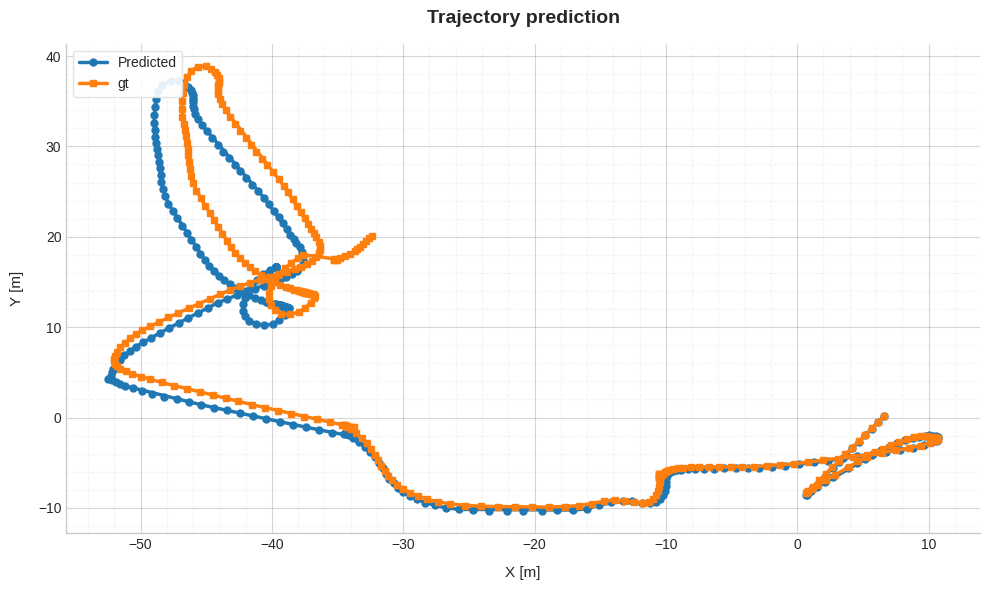

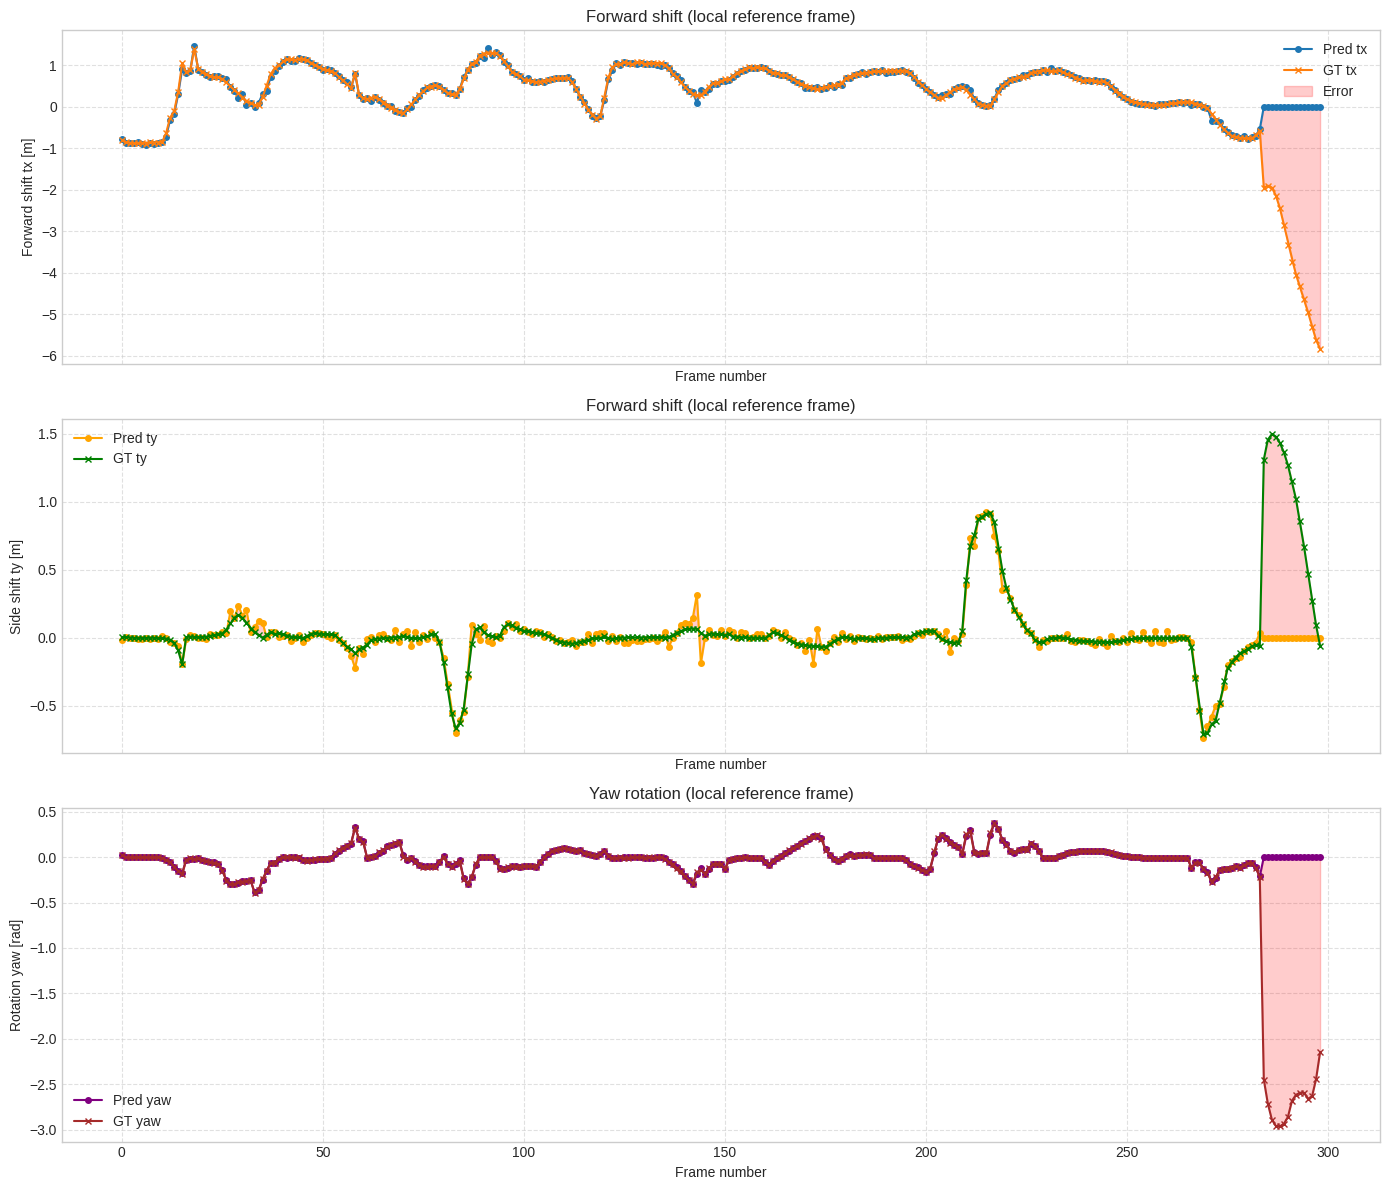

In [ ]:
# === visualise results ===

start = 0
end = -1

results = logger.get_metrics_dict()

pred_traj = np.stack((results['pred_x'], results['pred_y'], results['pred_theta']), axis = np.newaxis)
gt_traj = np.stack((results['gt_x'], results['gt_y'], results['gt_theta']), axis = np.newaxis)

# --- metrics ---
metrics = eval_metrics_2d(pred_traj[start:end, :], gt_traj[start:end, :]) 

In [ ]:
# --- trajectory 2d --- 
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

ax.plot(pred_traj[start:end, 0], pred_traj[start:end, 1], label='Estymowana', color = 'red', linewidth=2.5, marker='o', markersize=3)
ax.plot(gt_traj[start:end, 0], gt_traj[start:end, 1], label='Rzeczywista', color = 'black', linewidth=2.5, marker='s', markersize=3)

ax.plot(gt_traj[start, 0], gt_traj[start, 0], label='Start', color = 'blue', linewidth=2.5, marker='o', markersize=6)

ax.minorticks_on()
ax.grid(visible=True, which='major', color='#999999', linestyle='-', alpha=0.4)
ax.grid(visible=True, which='minor', color='#cccccc', linestyle='--', alpha=0.2)

ax.set_title('Trajektoria', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('X [m]', fontsize=11, labelpad=10)
ax.set_ylabel('Y [m]', fontsize=11, labelpad=10)

ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#e0e0e0', framealpha=0.9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()

plt.show()

In [ ]:
# --- trajectory 3d --- 

# Display only trajectory
fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=gt_traj[start:end], 
    y=gt_traj[start:end], 
    z=gt_traj[start:end],
    mode='Rzeczywista',
    name='gt',
    line=dict(color='black', width=4)
))

fig.add_trace(go.Scatter3d(
    x=pred_traj[start:end], 
    y=pred_traj[start:end], 
    z=pred_traj[start:end],
    mode='lines',
    name='Estymowana',
    line=dict(color='red', width=4)
))

fig.add_trace(go.Scatter3d(
    x=gt_traj[start], 
    y=gt_traj[start], 
    z=gt_traj[start],
    mode='Start',
    name='gt',
    line=dict(color='blue', width=4)
))

fig.update_layout(
    title="Trajektoria",
    scene=dict(
        xaxis_title=' X (m)',
        yaxis_title=' Y (m)',
        zaxis_title=' Z (m)',
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=0.5)
    ),
    width=900,
    height=700
)

fig.show()


In [ ]:
# --- Error per frame ---

step_pred_dx = results['step_pred_dx']
step_pred_dy = results['step_pred_dy']
step_pred_dtheta = results['step_pred_dtheta']

step_gt_dx = results['step_gt_dx']
step_gt_dy = results['step_gt_dy']
step_gt_dtheta = results['step_gt_dtheta']

fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
frames_num = np.arange(results['frame_id'].shape[0])

#  dTX
axs[0].plot(frames_num, step_pred_dx, label='Estymowane', marker='o', markersize=4)
axs[0].plot(frames_num, step_gt_dx, label='Rzeczywiste', marker='x', markersize=4)
axs[0].fill_between(frames_num, step_pred_dx, step_gt_dx, color='red', alpha=0.2, label='Error')
axs[0].set_ylabel('Dystans [m]')
axs[0].set_xlabel('Number klatki')
axs[0].set_title('Przesunięcie w przód względem ostatniej pozycji')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()

#  dTY
axs[1].plot(frames_num, step_pred_dy, label='Estymowane', marker='o', markersize=4, color='orange')
axs[1].plot(frames_num, step_gt_dy, label='Rzeczywiste', marker='x', markersize=4, color='green')
axs[1].fill_between(frames_num, step_pred_dy, step_gt_dy, color='red', alpha=0.2)
axs[1].set_ylabel('Dystans [m]')
axs[1].set_xlabel('Numer klatki')
axs[1].set_title('Przesunięcie w bok względem ostatniej pozycji')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend()

#  dYAW
axs[2].plot(frames_num, step_pred_dtheta, label='Estymowane', marker='o', markersize=4, color='purple')
axs[2].plot(frames_num, step_gt_dtheta, label='Rzeczywiste', marker='x', markersize=4, color='brown')
axs[2].fill_between(frames_num, step_pred_dtheta, step_gt_dtheta, color='red', alpha=0.2)
axs[2].set_ylabel('Kąt obrotu [rad]')
axs[2].set_title('Kierunek ruchu względem ostatniej pozycji')
axs[2].set_xlabel('Numer klatki')
axs[2].grid(True, linestyle='--', alpha=0.6)
axs[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# --- Diagnostic data ---  

fig, axs = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
frames_num = np.arange(results['frame_id'].shape[0])

#  inliers abs
axs[0].plot(frames_num, results['inliers_abs'], label='Ilość spójnych punktów (RANSAC)', marker='o', markersize=4)
axs[0].set_xlabel('Number klatki')
# axs[0].set_title('')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()

#  inliers ration and confidence
axs[1].plot(frames_num, results['inliers_ratio'], label='Udział spójnych punktów (RANSAC)', marker='o', markersize=4)
axs[1].plot(frames_num, results['condifence'], label='Pewność dopasowań', marker='o', markersize=4)
axs[1].set_xlabel('Number klatki')
# axs[0].set_title('')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend()


plt.tight_layout()
plt.show()

In [ ]:
# --- Time window diagnostic data ---  

fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
frames_num = np.arange(results['frame_id'].shape[0])

#  X
axs[0].plot(frames_num, results['est_std_x'], label='ruch w przód', marker='o', markersize=4)
axs[0].set_xlabel('Number klatki')
axs[0].set_title('Odchylenie standardowe [m]')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()

#  Y
axs[1].plot(frames_num, results['est_std_y'], label='ruch boczny', marker='o', markersize=4)
axs[1].set_xlabel('Number klatki')
axs[1].set_title('Odchylenie standardowe [m]')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend()

#  Yaw
axs[2].plot(frames_num, results['est_std_theta'], label='kierunek ruchu', marker='o', markersize=4)
axs[2].set_xlabel('Number klatki')
axs[2].set_title('Odchylenie standardowe [rad]')
axs[2].grid(True, linestyle='--', alpha=0.6)
axs[2].legend()

plt.tight_layout()
plt.show()


